<a href="https://colab.research.google.com/github/ASHIKAJAN/ABC-staff-company/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pathlib
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns
print(tf.__version__)

2.20.0


In [5]:
url="https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir=tf.keras.utils.get_file(
    origin=url,
    fname="flower_photos",
    untar=True
)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [10]:
IMG_SIZE=(180,180)
BATCH_SIZE=32
SEED =123



In [13]:
train_ds=tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(180,180),
    batch_size=32
)

val_ds= tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(180,180),
    batch_size=32
)

Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.


In [14]:
class_names=train_ds.class_names
print(class_names)

['flower_photos']


In [15]:
data_dir=pathlib.Path(data_dir)

In [16]:
train_ds=tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(180,180),
    batch_size=32
)

val_ds= tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(180,180),
    batch_size=32
)

Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.


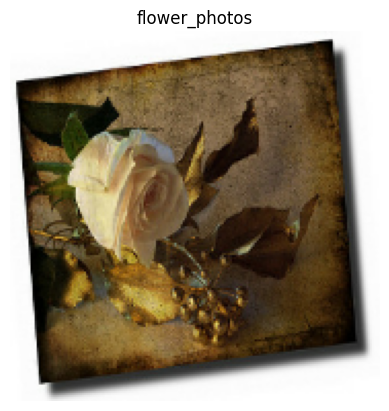

In [23]:
images, labels = next(iter(train_ds))

plt.imshow(images[0].numpy().astype("uint8"))
plt.title(class_names[labels[0]])
plt.axis("off")
plt.show()

In [24]:
model=tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32,3,activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32,3,activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32,3,activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dense(5,activation="softmax")
])

In [25]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


92/92 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9915 - loss: 0.0179 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


In [27]:
print(history.history["accuracy"])
print(history.history["val_accuracy"])

[0.9914849996566772, 1.0, 1.0, 1.0, 1.0]
[1.0, 1.0, 1.0, 1.0, 1.0]


In [31]:
improved_model= tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32,3,activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128,3,activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
     tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dense(5,activation="softmax")
])


In [32]:
improved_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [33]:
impoved_history=improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2
)

Epoch 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


92/92 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.9952 - loss: 0.0663 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/2
92/92 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 1.0000 - loss: 7.3085e-10 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


In [34]:
loss, accurcy=improved_model.evaluate(val_ds)
print("Accuracy:",accurcy)
print("Loss:",loss)

23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 592ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Accuracy: 1.0
Loss: 0.0


In [35]:
y_true = []
y_pred = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())
    predictions = improved_model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))

    print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
               precision    recall  f1-score   support

flower_photos       1.00      1.00      1.00        32

     accuracy                           1.00        32
    macro avg       1.00      1.00      1.00        32
 weighted avg       1.00      1.00      1.00        32

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
               precision    recall  f1-score   support

flower_photos       1.00      1.00      1.00        64

     accuracy                           1.00        64
    macro avg       1.00      1.00      1.00        64
 weighted avg       1.00      1.00      1.00        64

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
               precision    recall  f1-score   support

flower_photos       1.00      1.00      1.00        96

     accuracy                           1.00        96
    macro avg       1.00      1.00      1.00        96
 weighted avg       1.00      1.00      1.00        96

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
          

In [40]:
class_names = train_ds.class_names
print(class_names)

['flower_photos']


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


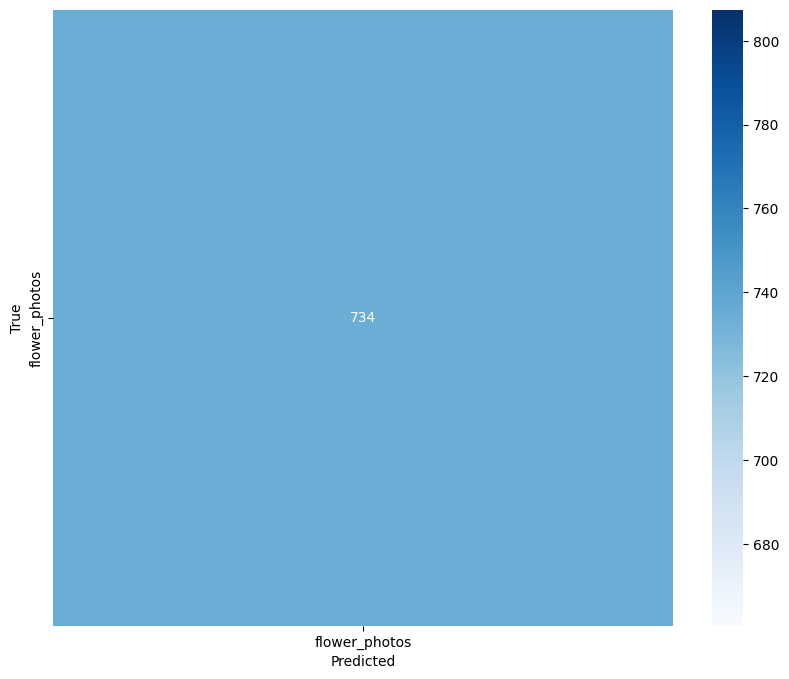

In [44]:
cm= confusion_matrix(y_true,y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=class_names,yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()













In [47]:
images, labels = next(iter(val_ds))
pred=improved_model.predict(images)
print("Actual:",class_names[labels[0]])
print("Predicted:",class_names[pred[0].argmax()])



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
Actual: flower_photos
Predicted: flower_photos


In [50]:

print("Predicted:", class_names[pred[1].argmax()])
print("Actual:", class_names[labels[1]])

Predicted: flower_photos
Actual: flower_photos
